# Large-Scale Traffic Accident Clustering with HDBSCAN and Ward Hierarchical Clustering

**Author:** Rodolfo Antonio González Salazar

## Description

This project applies unsupervised Machine Learning techniques to cluster large-scale traffic accident records from the **US Accidents** dataset.

The objective is to identify meaningful accident patterns using geographical, weather-related, road-condition, and traffic-control features. Since each accident record contains multiple numerical and boolean attributes, the project focuses on preprocessing the data, reducing dimensionality, and evaluating different clustering strategies.

Two different clustering approaches are evaluated and compared:

1. **HDBSCAN**, a density-based clustering algorithm capable of identifying clusters with arbitrary shapes and detecting noise points.
2. **Ward Hierarchical Clustering**, a hierarchical clustering method used to analyze fixed cluster structures.

The project also applies **Principal Component Analysis (PCA)** to reduce dimensionality while preserving most of the variance in the data before applying the clustering algorithms.


## Project Workflow

The project follows these main stages:

1. Data loading and sampling.
2. Feature selection.
3. Missing value analysis and preprocessing.
4. Outlier treatment.
5. Boolean feature conversion and feature scaling.
6. Dimensionality reduction using PCA.
7. HDBSCAN clustering.
8. Ward hierarchical clustering.
9. Internal clustering evaluation.
10. Visualization and cluster interpretation.


## 1. Imports and Project Configuration

This section imports the required libraries and defines local project paths for the dataset and generated outputs.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering

In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
from pathlib import Path

DATA_PATH = Path("data/US_Accidents_March23.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Download the US Accidents dataset and place the CSV file inside the data/ directory."
    )

## 2. Data Loading and Initial Inspection

The dataset is loaded from a local `data/` directory. Only a sample of 500,000 records is used to reduce memory usage and computational cost.


In [4]:
df = pd.read_csv(DATA_PATH, nrows=500000)

The dataset shape is inspected to confirm the number of loaded records and available features before preprocessing

In [5]:
df.shape

(500000, 46)

Inspect the types of variables

In [6]:
print(df.dtypes)

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump      

Visualize the ratio of missing values on the dataframe

In [7]:
# Inspect data types and missing-value ratios before feature selection

initial_overview = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_ratio": df.isnull().mean()
}).sort_values("missing_ratio", ascending=False)

initial_overview.head(20)

,dtype,missing_ratio
End_Lat,float64,1.000000
End_Lng,float64,1.000000
Precipitation(in),float64,0.896108
Wind_Chill(F),float64,0.875282
Wind_Speed(mph),float64,0.178080
Visibility(mi),float64,0.021078
Weather_Condition,object,0.020370
Humidity(%),float64,0.015830
Temperature(F),float64,0.014500
Pressure(in),float64,0.011478


## 3. Feature Selection

A subset of geographical, weather-related, road-condition, and traffic-control features is selected for clustering.

The selected variables include geographical coordinates, accident distance, weather conditions, and road-infrastructure indicators. These features were chosen because they provide complementary information about accident context while keeping the clustering problem computationally manageable.


In [8]:
selected_feat = ['Start_Lat',
       'Start_Lng', 'Distance(mi)',
        'Temperature(F)', 
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Speed(mph)',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'Railway',
       'Roundabout', 'Stop', 'Traffic_Signal'
       ]

In [9]:
df = df[selected_feat]
df.head()

,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal
0,39.865147,-84.058723,0.01,36.9,91.0,29.68,10.0,NaN,False,False,False,False,False,False,False,False
1,39.928059,-82.831184,0.01,37.9,100.0,29.65,10.0,NaN,False,False,False,False,False,False,False,False
2,39.063148,-84.032608,0.01,36.0,100.0,29.67,10.0,3.5,False,False,False,False,False,False,False,True
3,39.747753,-84.205582,0.01,35.1,96.0,29.64,9.0,4.6,False,False,False,False,False,False,False,False
4,39.627781,-84.188354,0.01,36.0,89.0,29.65,6.0,3.5,False,False,False,False,False,False,False,True


## 4. Missing Value Analysis

The selected features are inspected to identify missing values before applying imputation and outlier treatment


In [10]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": df.isna().mean()
}).sort_values("missing_ratio", ascending=False)

missing_summary

,missing_count,missing_ratio
Wind_Speed(mph),89040,0.178080
Visibility(mi),10539,0.021078
Humidity(%),7915,0.015830
Temperature(F),7250,0.014500
Pressure(in),5739,0.011478
Start_Lat,0,0.000000
Start_Lng,0,0.000000
Distance(mi),0,0.000000
Bump,0,0.000000
Crossing,0,0.000000


In [11]:
weather_numeric_features = ['Temperature(F)', 
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Speed(mph)']

## 5. Initial Distribution Analysis

The numerical weather-related variables are visualized to understand their distributions and identify potential outliers

Before applying imputation, the distributions of the weather-related numerical variables are inspected. This helps identify extreme values that may distort median imputation or affect distance-based clustering algorithms

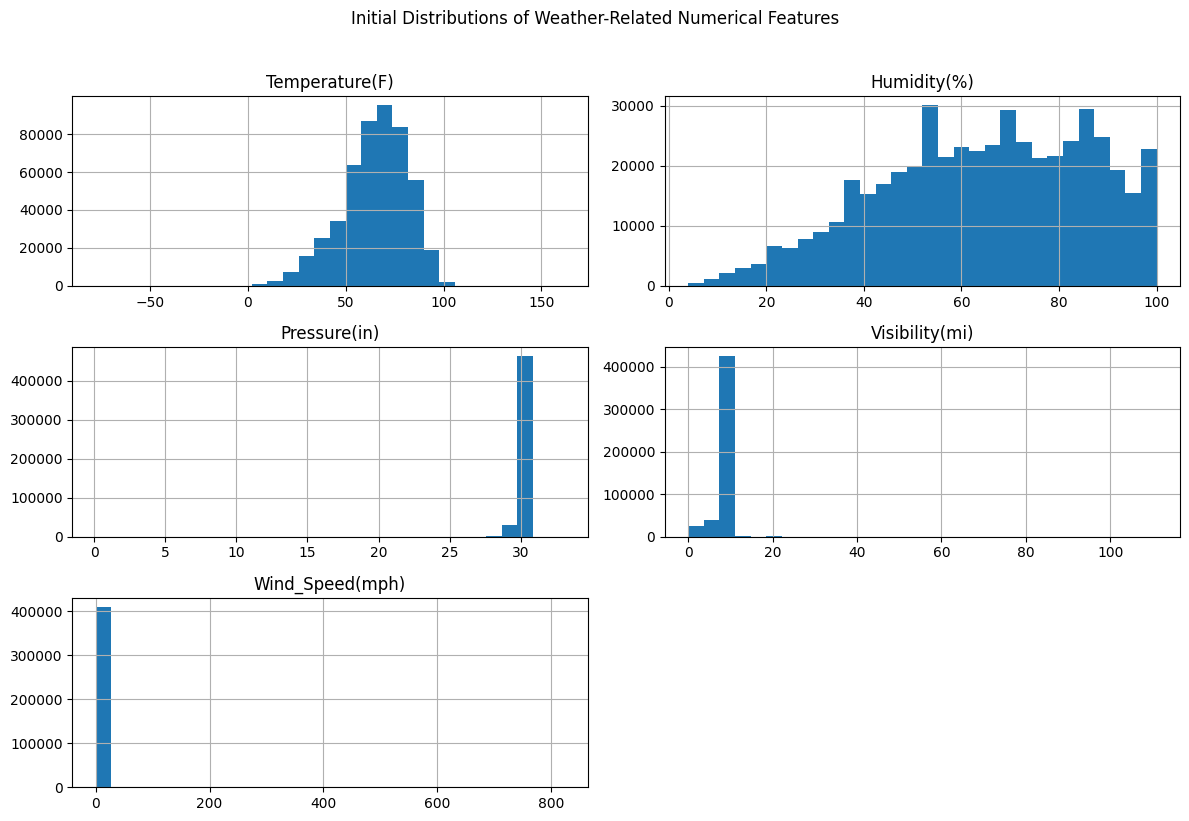

In [12]:
df[weather_numeric_features].hist(bins=30, figsize=(12, 8))
plt.suptitle("Initial Distributions of Weather-Related Numerical Features", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weather_features_initial_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

A descriptive summary is computed for the numerical features to detect unrealistic minimum or maximum values before scaling and clustering

In [13]:
numeric_features = [
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)"
]

In [14]:
df[numeric_features].describe()

,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
count,500000.000000,492750.000000,492085.000000,494261.000000,489461.000000,410960.000000
mean,0.065294,64.668092,64.529433,30.004807,9.227911,8.913004
std,0.782881,16.877594,21.387837,0.242343,2.140192,5.414922
min,0.000000,-77.800000,4.000000,0.120000,0.000000,0.000000
25%,0.000000,55.000000,49.000000,29.900000,10.000000,5.800000
50%,0.010000,66.200000,66.000000,30.000000,10.000000,8.100000
75%,0.010000,77.000000,82.000000,30.110000,10.000000,11.500000
max,90.370003,161.600000,100.000000,33.040000,111.000000,822.800000


## 6. Outlier Treatment and Median Imputation

Several weather-related variables contain extreme values that may not be physically plausible or may distort distance-based clustering algorithms. Since both HDBSCAN and Ward clustering rely on distances between observations, extreme numerical values can disproportionately influence the clustering structure.

The following preprocessing rules are applied based on empirical inspection of the feature distributions and reasonable domain constraints:

- Extremely high wind speed values are treated as missing
- Atmospheric pressure values outside a plausible range are treated as missing
- Extremely low or high temperature values are treated as missing
- Visibility is clipped to reduce the influence of very large values

After these corrections, missing values are imputed using the median, which is less sensitive to extreme values than the mean.


In [15]:
df['Wind_Speed(mph)'].sort_values(ascending=False).head(20)

114580    822.8
114588    822.8
114633    822.8
114640    822.8
114647    822.8
64265     241.7
491511    174.9
134892    162.3
17802     142.7
288672    127.7
247668    126.6
247672    126.6
247674    126.6
478379    126.6
247720    126.6
113147    123.1
113131    123.1
113098    100.1
113839    100.1
113099    100.1
Name: Wind_Speed(mph), dtype: float64

### Wind Speed Outlier Treatment

The maximum wind speed values were inspected because some records contained extremely large values that are unlikely to represent realistic observations. Values above 250 mph are treated as outliers and replaced with missing values before median imputation.


In [16]:
df.loc[df['Wind_Speed(mph)'] > 250, 'Wind_Speed(mph)'] = np.nan

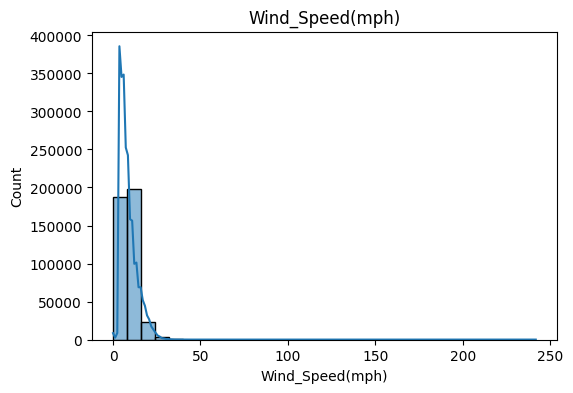

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['Wind_Speed(mph)'], bins=30, kde=True)
plt.title('Wind_Speed(mph)')
plt.show()

In [18]:
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())

Based on the descriptive statistics and distribution plots, similar preprocessing rules were applied to the remaining weather-related numerical features. Instead of inspecting each feature in separate exploratory cells, the outlier treatment is consolidated below to keep the notebook concise and reproducible

In [19]:
# Treat implausible atmospheric pressure values as missing

df.loc[
    (df["Pressure(in)"] < 20) | (df["Pressure(in)"] > 32),
    "Pressure(in)"
] = np.nan

# Treat extreme temperature values as missing

df.loc[
    (df["Temperature(F)"] < -14) | (df["Temperature(F)"] > 139),
    "Temperature(F)"
] = np.nan

# Cap visibility values to reduce the influence of extreme distances

df["Visibility(mi)"] = df["Visibility(mi)"].clip(upper=10)

In [20]:
df[weather_numeric_features].describe()

,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
count,492743.000000,492085.000000,494250.000000,489461.000000,500000.000000
mean,64.668739,64.529433,30.005279,9.202974,8.760077
std,16.871551,21.387837,0.213886,2.058144,4.191660
min,-13.000000,4.000000,20.040000,0.000000,0.000000
25%,55.000000,49.000000,29.900000,10.000000,5.800000
50%,66.200000,66.000000,30.000000,10.000000,8.100000
75%,77.000000,82.000000,30.110000,10.000000,10.400000
max,136.400000,100.000000,31.030000,10.000000,241.700000


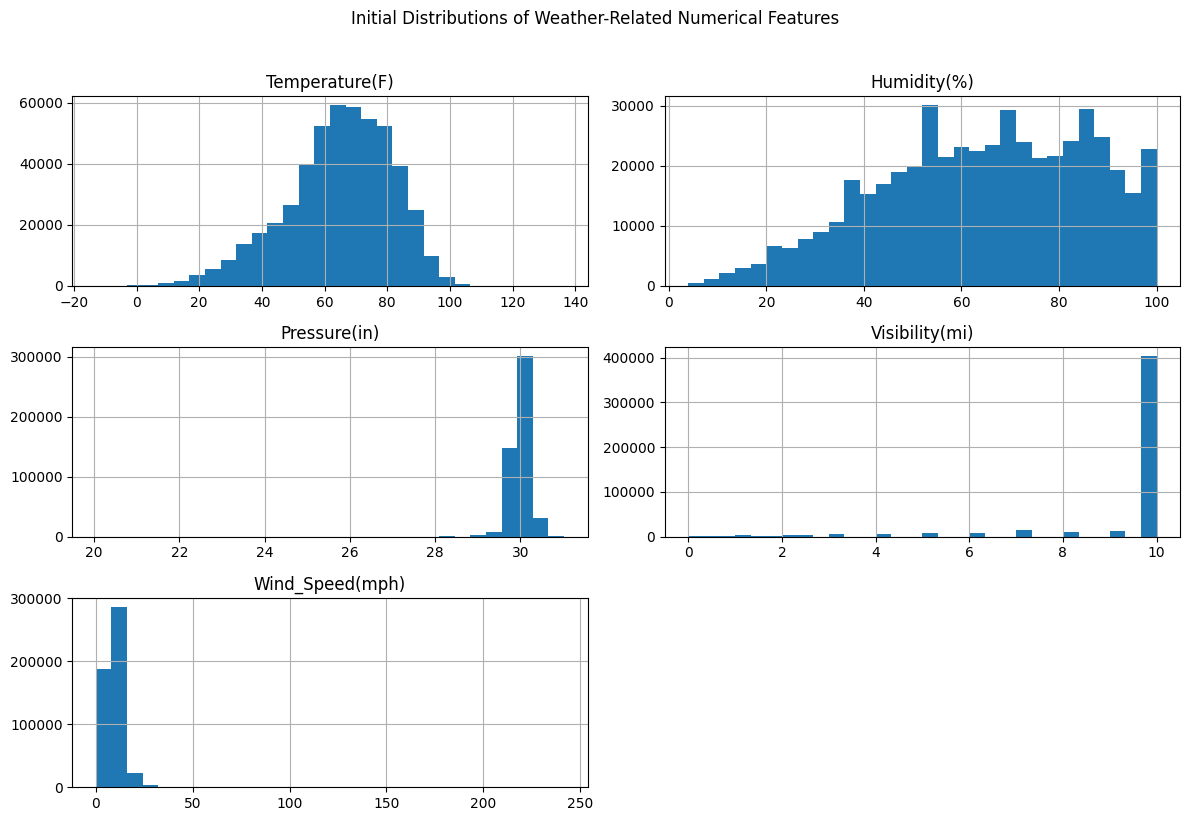

In [21]:
df[weather_numeric_features].hist(bins=30, figsize=(12, 8))
plt.suptitle(
    "Initial Distributions of Weather-Related Numerical Features",
    y=1.02
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "weather_features_initial_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Missing values in the weather-related numerical features are imputed using the median. The median was selected because it is less sensitive to extreme values than the mean, which is important after identifying skewed distributions and outliers in these variables

In [22]:
df[weather_numeric_features] = df[weather_numeric_features].fillna(
    df[weather_numeric_features].median()
)

In [23]:
df[weather_numeric_features].isna().sum()

Temperature(F)     0
Humidity(%)        0
Pressure(in)       0
Visibility(mi)     0
Wind_Speed(mph)    0
dtype: int64

## 7. Boolean Feature Encoding

The selected road-infrastructure variables are stored as boolean values. Since clustering algorithms operate on numerical representations, these features are converted into binary integer variables, where `True` is represented as `1` and `False` as `0`.

This preserves the meaning of the original indicators while allowing them to be used together with the numerical features during scaling and clustering.

In [24]:
bool_features = [
            'Bump', 'Crossing', 'Give_Way', 'Junction',
            'Railway', 'Roundabout', 'Stop', 'Traffic_Signal'
            ]
df[bool_features] = df[bool_features].astype(int)
df[bool_features].head()

,Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1


In [25]:
feature_types = pd.DataFrame({
    "dtype": df.dtypes
})

feature_types

,dtype
Start_Lat,float64
Start_Lng,float64
Distance(mi),float64
Temperature(F),float64
Humidity(%),float64
Pressure(in),float64
Visibility(mi),float64
Wind_Speed(mph),float64
Bump,int64
Crossing,int64


## 8. Feature Scaling

The selected features have different numerical ranges. For example, geographical coordinates, distance, weather measurements, and binary road-infrastructure indicators are represented on different scales.

Since HDBSCAN and Ward clustering rely on distance-based calculations, feature scaling is required to prevent variables with larger numerical ranges from dominating the clustering process. Standardization is applied so that each feature has approximately zero mean and unit variance.

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(f"Scaled feature matrix shape: {X_scaled.shape}")

Scaled feature matrix shape: (500000, 16)


## 9. Dimensionality Reduction with PCA

Principal Component Analysis (PCA) is applied after feature scaling to reduce the dimensionality of the dataset while preserving most of the variance in the original feature space.

This step is useful because clustering algorithms such as HDBSCAN can become computationally expensive on large datasets. By retaining 90% of the explained variance, PCA provides a more compact representation of the data while keeping most of the information needed for clustering.

In [27]:
X_scaled_c = np.ascontiguousarray(X_scaled, dtype=np.float64)

pca = PCA(n_components=0.90, svd_solver="full", random_state=42)
X_pca = pca.fit_transform(X_scaled_c)

print("X_pca shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())


X_pca shape: (500000, 13)
Explained variance: 0.9103268019353189


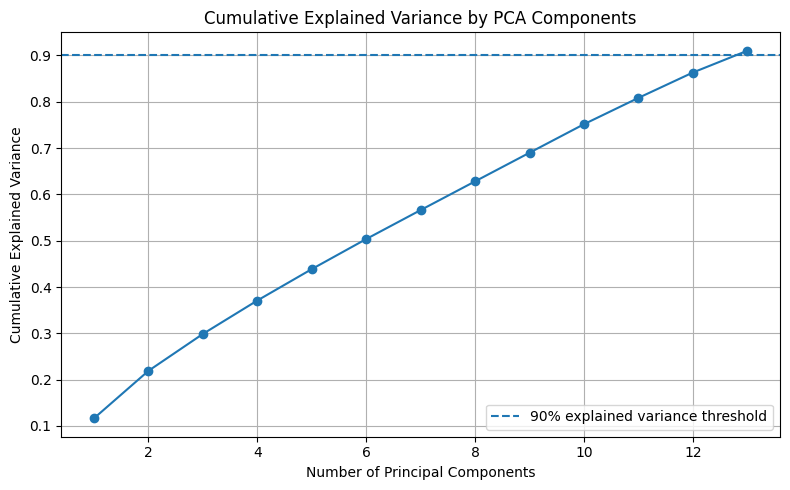

In [28]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.axhline(y=0.90, linestyle="--", label="90% explained variance threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "pca_cumulative_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 10. HDBSCAN Clustering

HDBSCAN is applied to the PCA-transformed feature matrix to identify dense accident patterns without requiring the number of clusters to be specified in advance.

This is useful for large-scale accident data because the underlying structure may contain clusters with irregular shapes and varying densities. HDBSCAN can also label observations as noise, which helps separate less consistent accident patterns from denser groups.

The selected parameters control the minimum size of a cluster, the level of local density required, and the cluster selection strategy.

In [29]:
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels_hdb = hdbscan_model.fit_predict(X_pca)

df["hdbscan_cluster"] = labels_hdb

unique, counts = np.unique(labels_hdb, return_counts=True)

print(f"Number of clusters without noise: {(unique != -1).sum()}")
print(f"Noise ratio: {(labels_hdb == -1).mean():.2%}")

Number of clusters without noise: 114
Noise ratio: 29.71%


Before computing clustering quality metrics, noise points identified by HDBSCAN are removed. HDBSCAN assigns label `-1` to observations that do not belong strongly to any dense cluster, so these points are excluded from the internal validation metrics.

In [30]:
# Exclude noise points before evaluating HDBSCAN cluster quality
mask = labels_hdb != -1

X_eval = X_pca[mask]
y_eval = labels_hdb[mask]

unique, counts = np.unique(y_eval, return_counts=True)

print(f"Number of non-noise points: {X_eval.shape[0]}")
print(f"Minimum HDBSCAN cluster size: {counts.min()}")

Number of non-noise points: 351433
Minimum HDBSCAN cluster size: 153


### HDBSCAN Internal Validation Metrics

Internal validation metrics are computed only on non-noise observations. Since HDBSCAN assigns label `-1` to noise points, these observations are excluded from the evaluation to avoid distorting the cluster quality metrics.

The following metrics are used:

- **Davies-Bouldin Score:** measures average similarity between clusters. Lower values are better
- **Calinski-Harabasz Score:** measures the ratio between between-cluster and within-cluster dispersion. Higher values are better

In [31]:
print("Davies-Bouldin:", davies_bouldin_score(X_eval, y_eval))
print("Calinski-Harabasz:", calinski_harabasz_score(X_eval, y_eval))

Davies-Bouldin: 2.3315311226339848
Calinski-Harabasz: 6961.44537968596


## 11. HDBSCAN Visualization

The resulting HDBSCAN clusters are visualized from two complementary perspectives. First, a two-dimensional PCA projection is used to inspect the separation of clusters in the transformed feature space. Then, a geographical scatter plot is used to observe how the detected accident patterns are distributed across latitude and longitude.

In both visualizations, noise points are included using the label `-1`, which allows the spatial and feature-space distribution of unassigned observations to be inspected as well.

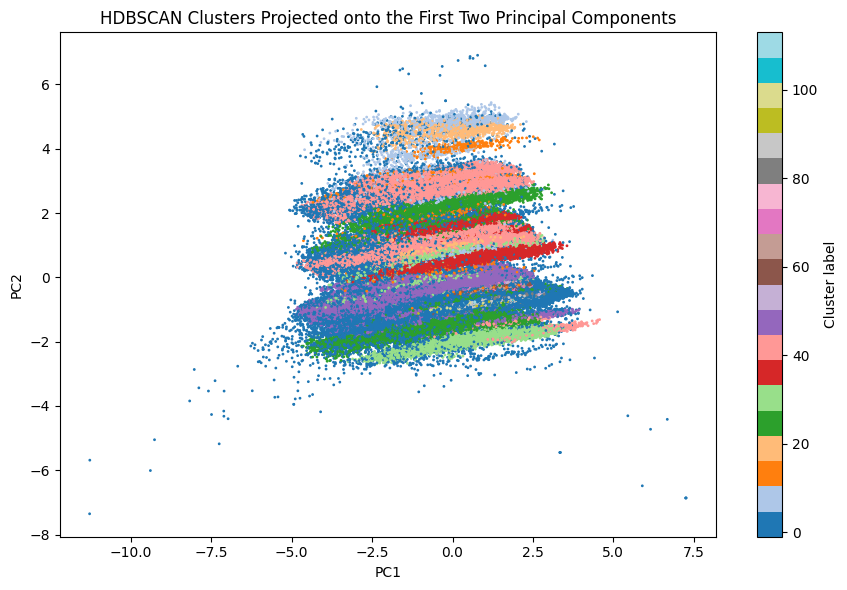

In [32]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_hdb,
    s=1,
    cmap="tab20"
)
plt.title("HDBSCAN Clusters Projected onto the First Two Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster label")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "hdbscan_pca_projection.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The geographical scatter plot shows how HDBSCAN cluster assignments are distributed across longitude and latitude. This visualization helps connect the clustering results back to the real spatial context of the accident data

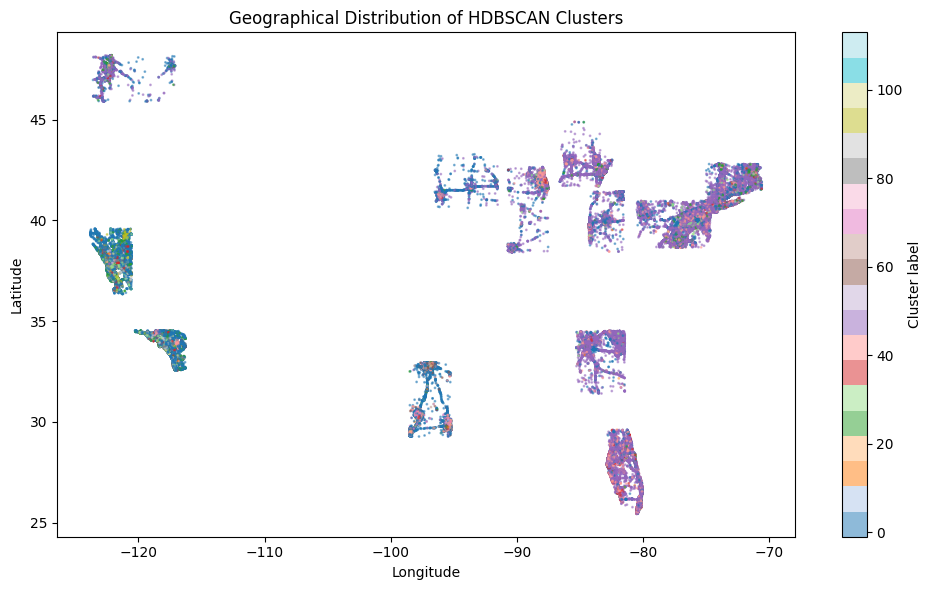

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Start_Lng"],
    df["Start_Lat"],
    c=labels_hdb,
    s=1,
    alpha= 0.5,
    cmap="tab20"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of HDBSCAN Clusters")
plt.colorbar(label="Cluster label")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "hdbscan_geographical_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The PCA projection helps inspect cluster separation in the transformed feature space, while the geographical plot shows whether the detected clusters correspond to spatial accident patterns. Since HDBSCAN is density-based, the presence of observations labeled as noise is expected in heterogeneous real-world accident data.

## 12. HDBSCAN without Geographical Coordinates

A second HDBSCAN experiment is performed without latitude and longitude to evaluate how much geographical location influences the clustering structure.


In [34]:
no_geo_features = [
 'Distance(mi)','Temperature(F)',
 'Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)',
 'Bump','Crossing','Give_Way','Junction','Railway',
 'Roundabout','Stop','Traffic_Signal'
]

df_no_geo = df[no_geo_features].copy()

In [35]:
scaler_no_geo = StandardScaler()
X_scaled_no_geo = scaler_no_geo.fit_transform(df_no_geo)

pca_no_geo = PCA(n_components=0.90, svd_solver="full")
X_pca_no_geo = pca_no_geo.fit_transform(X_scaled_no_geo)

print(f"Feature matrix without geographical coordinates: {df_no_geo.shape}")
print(f"PCA-transformed matrix without geographical coordinates: {X_pca_no_geo.shape}")
print(f"Explained variance retained: {pca_no_geo.explained_variance_ratio_.sum():.2%}")

Feature matrix without geographical coordinates: (500000, 14)
PCA-transformed matrix without geographical coordinates: (500000, 12)
Explained variance retained: 93.00%


The same HDBSCAN configuration is used as in the previous experiment to make the comparison more direct. In this version, only the geographical coordinates are removed from the feature set.

In [36]:
clusterer_no_geo = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels_no_geo = clusterer_no_geo.fit_predict(X_pca_no_geo)

print(
    "Clusters without noise:",
    len(set(labels_no_geo)) - (1 if -1 in labels_no_geo else 0)
)
print(f"Noise ratio: {(labels_no_geo == -1).mean():.2%}")

Clusters without noise: 134
Noise ratio: 45.68%


In [37]:
mask_no_geo = labels_no_geo != -1

X_eval_no_geo = X_pca_no_geo[mask_no_geo]
y_eval_no_geo = labels_no_geo[mask_no_geo]

unique_no_geo, counts_no_geo = np.unique(y_eval_no_geo, return_counts=True)

print(f"Number of non-noise points: {X_eval_no_geo.shape[0]}")
print(f"Minimum HDBSCAN cluster size: {counts_no_geo.min()}")

Number of non-noise points: 271597
Minimum HDBSCAN cluster size: 151


In [38]:
hdb_no_geo_davies_bouldin = davies_bouldin_score(
    X_eval_no_geo,
    y_eval_no_geo
)

hdb_no_geo_calinski_harabasz = calinski_harabasz_score(
    X_eval_no_geo,
    y_eval_no_geo
)

print(f"HDBSCAN without geo Davies-Bouldin Score: {hdb_no_geo_davies_bouldin:.4f}")
print(f"HDBSCAN without geo Calinski-Harabasz Score: {hdb_no_geo_calinski_harabasz:.2f}")

HDBSCAN without geo Davies-Bouldin Score: 3.3379
HDBSCAN without geo Calinski-Harabasz Score: 12587.63


## 13. Ward Hierarchical Clustering

Ward hierarchical clustering is evaluated on a sample of the PCA-transformed data because this method is computationally expensive for large datasets.

For this reason, a reproducible sample is used to evaluate different values of `k`. The goal is to compare cluster quality across several candidate cluster counts using internal validation metrics

In [39]:
rng = np.random.default_rng(42)
idx_ward = rng.choice(X_pca.shape[0], size=25000, replace=False)

X_ward = X_pca[idx_ward]

Different values of `k` are evaluated to analyze the trade-off between cluster compactness, separation, and interpretability. Since Ward clustering requires the number of clusters to be specified in advance, internal validation metrics are computed for each candidate value

In [40]:
ward_results = []

for k in range(2, 11):
    ward = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_w = ward.fit_predict(X_ward)
    
    sil = silhouette_score(X_ward, labels_w)
    db = davies_bouldin_score(X_ward, labels_w)
    ch = calinski_harabasz_score(X_ward, labels_w)
    
    ward_results.append({
        "k": k,
        "silhouette_score": sil,
        "davies_bouldin_score": db,
        "calinski_harabasz_score": ch,
    })

ward_results_df = pd.DataFrame(ward_results)
ward_results_df

,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,0.974069,0.027654,4389.108245
1,3,0.686363,0.332201,3544.227048
2,4,0.163693,1.215442,3383.397679
3,5,0.192794,1.145094,3386.845927
4,6,0.195266,0.956213,3521.361900
5,7,0.228952,0.968286,3732.096585
6,8,0.212734,0.869419,4049.900320
7,9,0.200826,1.051688,4288.214192
8,10,0.224740,0.974236,4520.588062


Although `k=2` may produce a strong Silhouette Score, it results in very broad clusters that may be less useful for interpretation. A larger value such as `k=8` provides a more detailed partition of the accident patterns while maintaining competitive Davies-Bouldin and Calinski-Harabasz scores

After selecting `k=8`, Ward clustering is applied to the same reproducible sample used during evaluation. The resulting labels are visualized geographically using the sampled latitude and longitude values

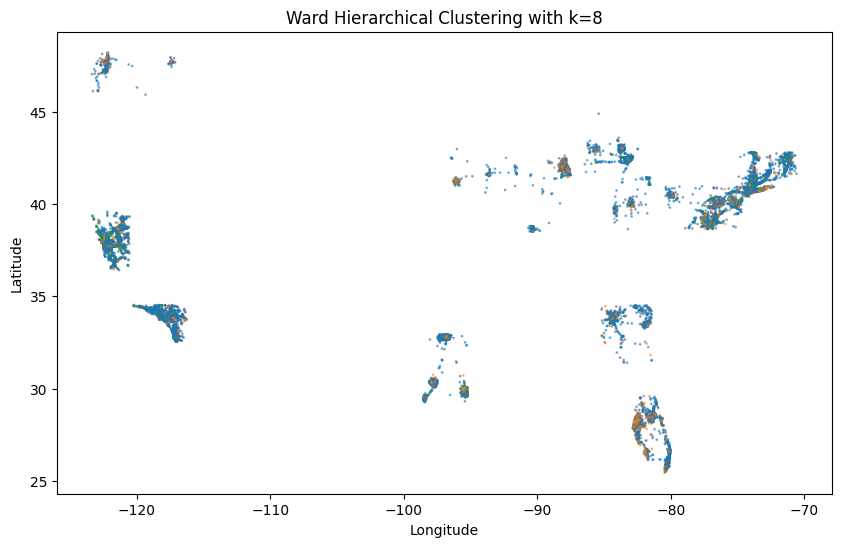

In [41]:
lat_w = df.iloc[idx_ward]["Start_Lat"].to_numpy()
lng_w = df.iloc[idx_ward]["Start_Lng"].to_numpy()

ward = AgglomerativeClustering(n_clusters=8, linkage="ward")
labels_w = ward.fit_predict(X_ward)

plt.figure(figsize=(10, 6))
plt.scatter(
    lng_w,
    lat_w,
    c=labels_w,
    s=1,
    alpha=0.5,
    cmap="tab10"
)
plt.title("Ward Hierarchical Clustering with k=8")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig(
    OUTPUT_DIR / "ward_k8_geographical_sample.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 14. Cluster Interpretation

To interpret the detected accident patterns, cluster-level feature averages are computed. This helps identify how clusters differ in terms of accident distance, weather conditions, road-infrastructure indicators, and geographical location.

For HDBSCAN, noise points labeled as `-1` are excluded from the interpretation because they do not belong strongly to any dense cluster

In [42]:
df.columns

Index(['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'Railway', 'Roundabout',
       'Stop', 'Traffic_Signal', 'hdbscan_cluster'],
      dtype='object')

In [43]:
df2 = df.copy()
hdbscan_cluster_profiles = (
    df2[df2["hdbscan_cluster"] != -1]
    .groupby("hdbscan_cluster")
    .mean(numeric_only=True)
)

hdbscan_cluster_profiles.head()

,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal
hdbscan_cluster,,,,,,,,,,,,,,,,
0,37.867572,-98.324125,0.055702,62.196930,68.258772,30.001798,9.054825,8.774561,0.0,0.289474,1.0,0.008772,0.0,0.0,1.0,0.083333
1,37.060314,-102.565215,0.003839,63.542654,62.199052,30.027014,9.079621,8.982464,0.0,0.909953,0.0,0.004739,1.0,0.0,1.0,0.061611
2,34.903786,-113.082532,0.016827,64.452209,67.317269,29.996426,9.442972,8.338554,0.0,0.072289,0.0,1.000000,1.0,0.0,0.0,0.028112
3,37.884123,-94.445240,0.070125,63.553750,60.266667,30.012625,9.226250,7.862917,0.0,0.170833,0.0,1.000000,0.0,0.0,1.0,0.020833
4,36.635753,-85.363789,0.011593,63.401828,66.821149,30.026175,9.183159,8.409791,0.0,0.000000,1.0,0.000000,0.0,0.0,0.0,0.000000


The table shows the average feature values for the first HDBSCAN clusters. For binary road-infrastructure variables, the mean represents the proportion of accidents in that cluster where the condition is present. For example, cluster 0 has `Give_Way = 1.0` and `Stop = 1.0`, meaning that all sampled accidents in that cluster are associated with those indicators, while `Crossing = 0.289` indicates that approximately 28.9% of accidents in that cluster occurred near a crossing.

These initial cluster profiles suggest that HDBSCAN is separating accident groups based on a combination of geographical location and road-infrastructure indicators. Some clusters are strongly associated with specific binary conditions, such as `Give_Way`, `Junction`, `Railway`, or `Stop`, while weather-related averages remain relatively similar across the displayed clusters

In [44]:
selected_profile_features = [
    "Distance(mi)",
    "Temperature(F)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Crossing",
    "Give_Way",
    "Junction",
    "Railway",
    "Stop",
    "Traffic_Signal",
]

hdbscan_cluster_profiles[selected_profile_features].head(10)

,Distance(mi),Temperature(F),Visibility(mi),Wind_Speed(mph),Crossing,Give_Way,Junction,Railway,Stop,Traffic_Signal
hdbscan_cluster,,,,,,,,,,
0,0.055702,62.196930,9.054825,8.774561,0.289474,1.0,0.008772,0.0,1.0,0.083333
1,0.003839,63.542654,9.079621,8.982464,0.909953,0.0,0.004739,1.0,1.0,0.061611
2,0.016827,64.452209,9.442972,8.338554,0.072289,0.0,1.000000,1.0,0.0,0.028112
3,0.070125,63.553750,9.226250,7.862917,0.170833,0.0,1.000000,0.0,1.0,0.020833
4,0.011593,63.401828,9.183159,8.409791,0.000000,1.0,0.000000,0.0,0.0,0.000000
5,0.009607,70.214581,9.375905,8.771665,1.000000,1.0,0.000000,0.0,0.0,1.000000
6,0.005932,60.237288,9.954802,8.337853,0.000000,0.0,0.000000,1.0,0.0,0.000000
7,0.006005,66.409845,9.568674,8.003173,0.000000,0.0,0.000000,1.0,0.0,0.000000
8,0.007849,61.044622,9.277291,8.923506,1.000000,0.0,0.000000,0.0,1.0,1.000000


The displayed profiles suggest that HDBSCAN captures accident groups influenced by a combination of geographical location, road infrastructure, and weather-related conditions.

## 15. Conclusions

This project applied unsupervised learning techniques to identify accident patterns in a large-scale traffic accident dataset. The workflow included feature selection, missing-value treatment, outlier handling, feature scaling, dimensionality reduction with PCA, and clustering using HDBSCAN and Ward hierarchical clustering.

HDBSCAN was useful because it identified dense accident patterns without requiring the number of clusters to be specified in advance. It also labeled a portion of the observations as noise, which is expected in heterogeneous real-world accident data where not all records belong clearly to a dense group.

The experiment without geographical coordinates showed that latitude and longitude have an important influence on the clustering structure. Removing those variables allows the model to focus on weather, accident-distance, and road-infrastructure characteristics, making it possible to compare spatially driven clustering against non-spatial accident patterns.

Ward Hierarchical Clustering provided a complementary perspective by evaluating different values of `k` on a reproducible sample. Although smaller values of `k` can produce strong internal validation scores, a larger value such as `k=8` provides more detailed and interpretable accident groupings.

Overall, the results suggest that clustering can help summarize large-scale accident data into meaningful groups, but the interpretation of the clusters depends strongly on preprocessing choices, feature selection, and whether geographical coordinates are included.